In [52]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [53]:
df = pd.read_csv('train.csv',usecols=['Age','Survived','Fare'])

In [54]:
df.head(3)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250


In [55]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_706/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [56]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [57]:
X=df.iloc[:,1:3]
X.head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [58]:
y=df.iloc[:,0]
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [59]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'QQ PLOT OF AGE')

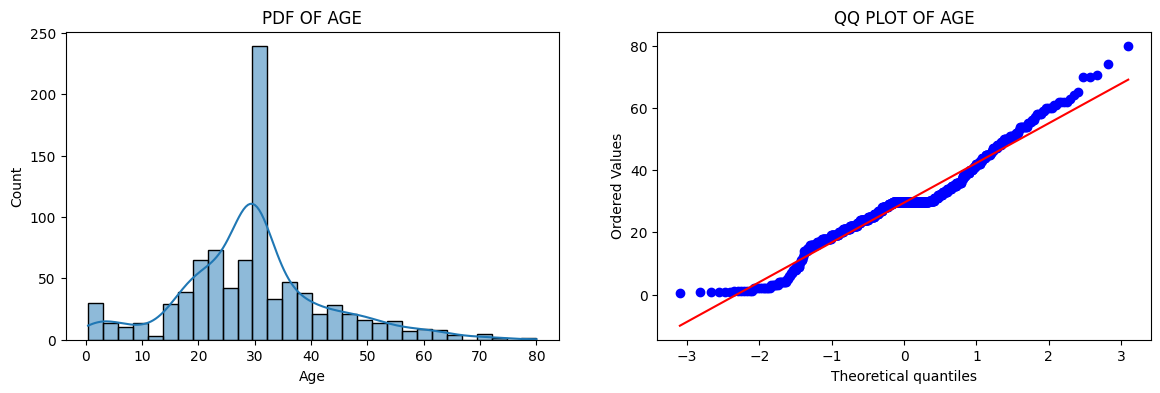

In [60]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(data=df, x='Age', kde=True)
plt.title('PDF OF AGE')

plt.subplot(122)
stats.probplot(X_train['Age'],plot=plt,dist='norm')
plt.title('QQ PLOT OF AGE')

Text(0.5, 1.0, 'QQ PLOT OF Fare')

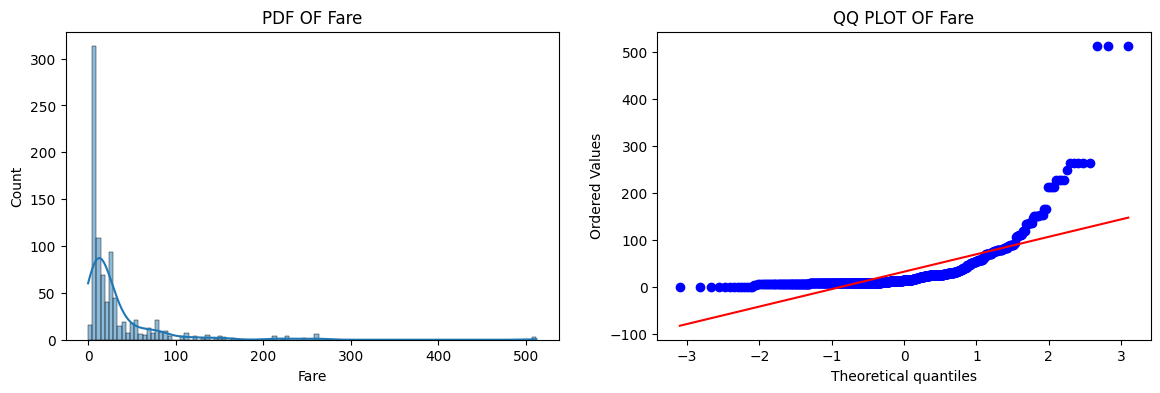

In [61]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(data=df, x='Fare', kde=True)
plt.title('PDF OF Fare')

plt.subplot(122)
stats.probplot(X_train['Fare'],plot=plt,dist='norm')
plt.title('QQ PLOT OF Fare')

In [62]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred=clf1.predict(X_test)
y_pred_1=clf2.predict(X_test)

print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred_1))

Accuracy of LR 0.6480446927374302
Accuracy of DT 0.6759776536312849


In [63]:
trf=FunctionTransformer(func=np.log1p)

In [64]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.fit_transform(X_test)

In [65]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred=clf1.predict(X_test_transformed)
y_pred_1=clf2.predict(X_test_transformed)

print("Accuracy of LR",accuracy_score(y_test,y_pred))
print("Accuracy of DT",accuracy_score(y_test,y_pred_1))

Accuracy of LR 0.6815642458100558
Accuracy of DT 0.664804469273743


In [70]:
X_transformed=trf.fit_transform(X)

clf1=LogisticRegression()
clf2=DecisionTreeClassifier()

print("Accuracy Of LR",cross_val_score(clf1,X_transformed,y,cv=10,scoring='accuracy'))
print("Accuracy Of DT",cross_val_score(clf2,X_transformed,y,cv=10,scoring='accuracy'))

Accuracy Of LR [0.55555556 0.57303371 0.68539326 0.74157303 0.66292135 0.71910112
 0.71910112 0.70786517 0.75280899 0.66292135]
Accuracy Of DT [0.64444444 0.66292135 0.58426966 0.65168539 0.66292135 0.6741573
 0.71910112 0.66292135 0.61797753 0.6741573 ]


Text(0.5, 1.0, 'QQ PLOT OF AGE After')

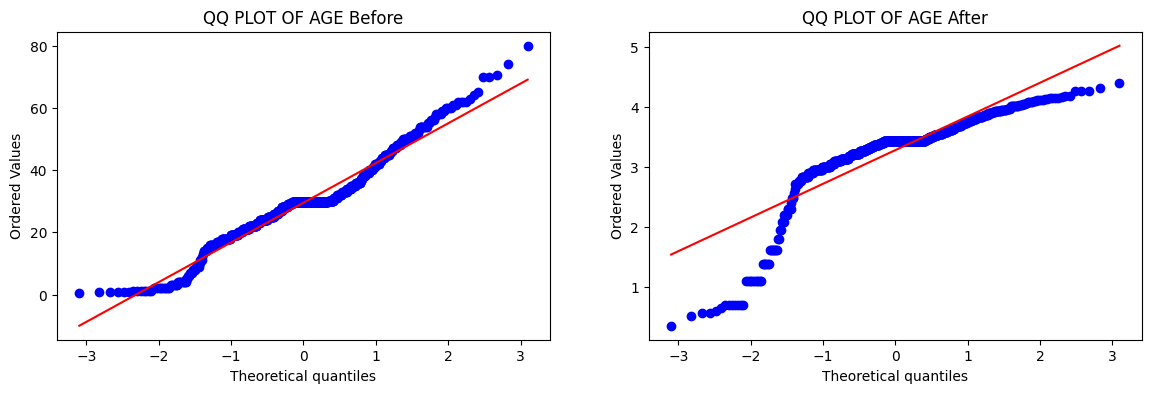

In [72]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],plot=plt,dist='norm')
plt.title('QQ PLOT OF AGE Before')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],plot=plt,dist='norm')
plt.title('QQ PLOT OF AGE After')

Text(0.5, 1.0, 'QQ PLOT OF Fare After')

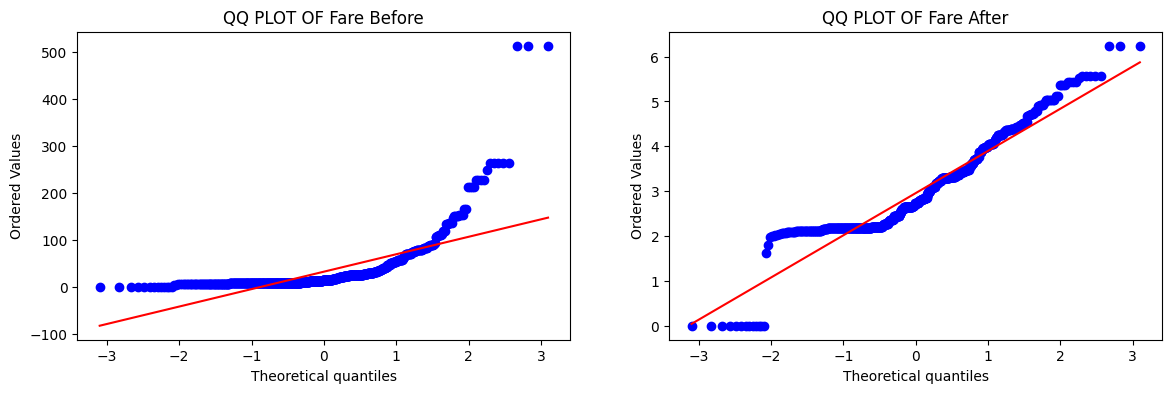

In [77]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],plot=plt,dist='norm')
plt.title('QQ PLOT OF Fare Before')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],plot=plt,dist='norm')
plt.title('QQ PLOT OF Fare After')


In [79]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6589013732833957


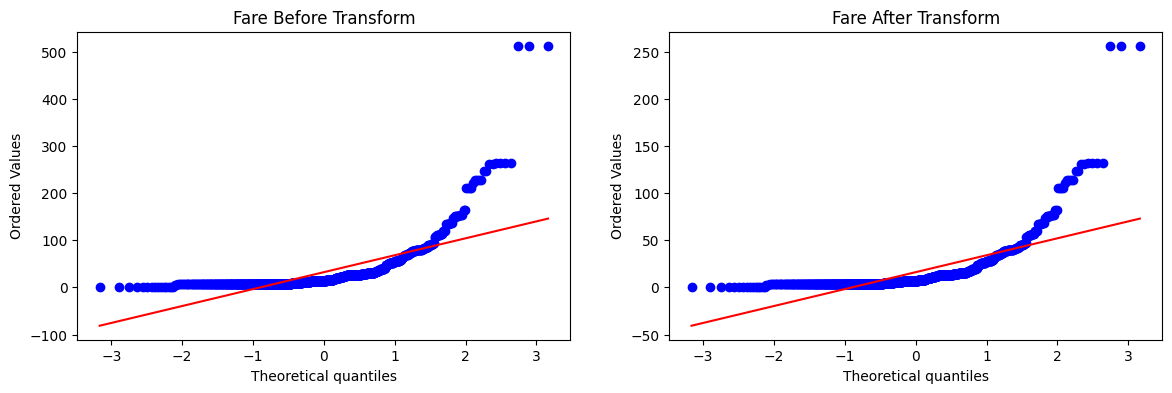

In [84]:
apply_transform(lambda x: x**1/2)

Accuracy 0.6431335830212235


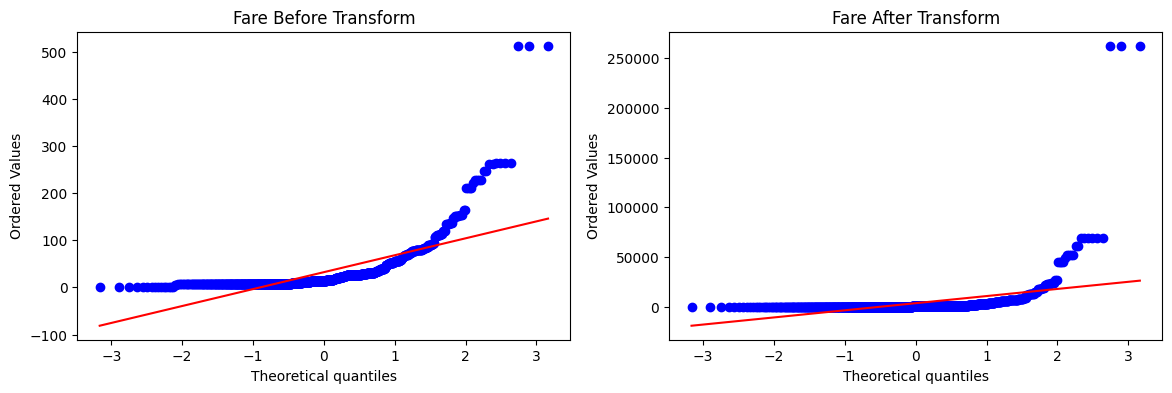

In [85]:
apply_transform(lambda x: x**2)

Accuracy 0.6712609238451936


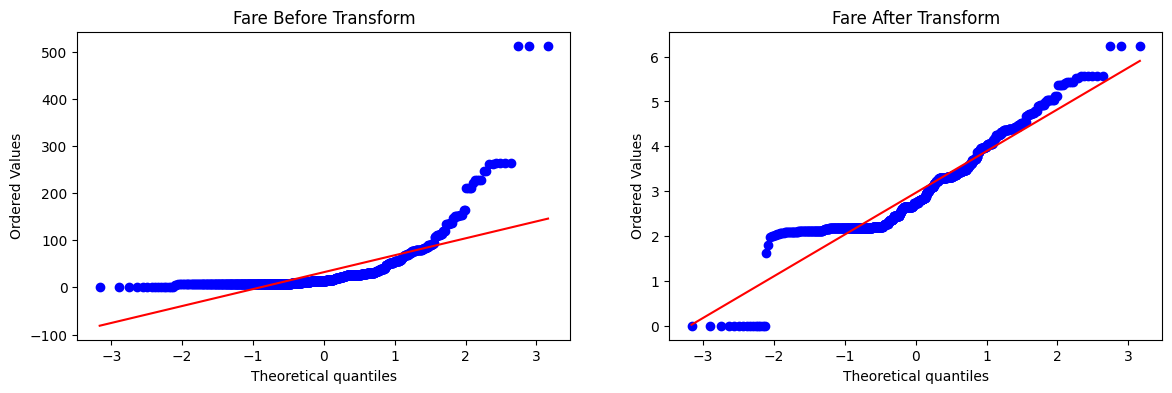

In [87]:
apply_transform(lambda x: np.log1p(x))

Accuracy 0.61729088639201


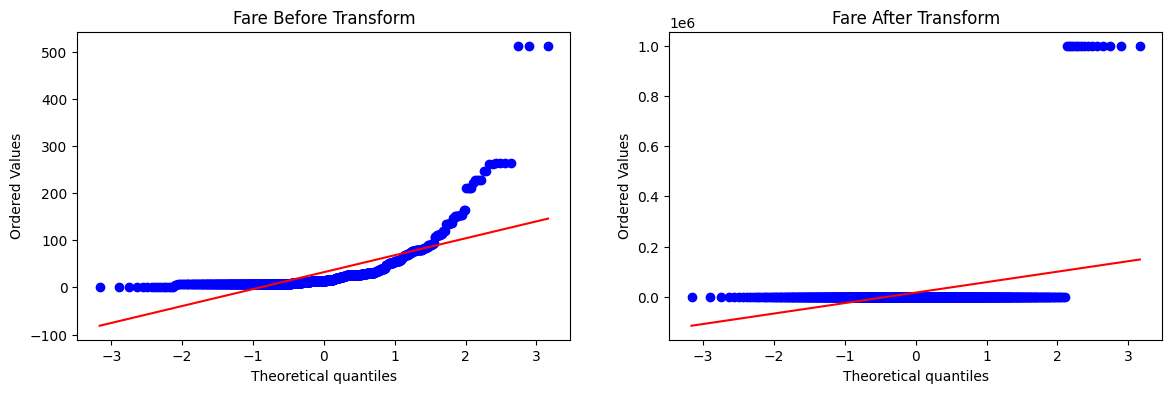

In [88]:
apply_transform(lambda x: 1/(x+0.000001))